<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Logistic Regression — Breast Cancer Diagnosis</h1>
<p align="center"><i>Notebook 3 — Training, evaluating, and understanding logistic regression under imbalance</i></p>

---

## 1. Logistic Regression, from First Principles

### 1.1 From linear regression to a probability

Linear regression predicts an unbounded real number $z = \theta^T x$. For classification we
need a **probability** between 0 and 1. The **sigmoid (logistic) function** squashes any real
number into that range:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = \theta^T x = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$$

The model's predicted probability that a sample belongs to the positive class (`malignant`)
is:

$$h_\theta(x) = \sigma(\theta^T x) = P(y = 1 \mid x)$$

### 1.2 Log-odds: the linear part of the model

Rearranging the sigmoid gives the **logit** (log-odds) — the quantity that is actually
*linear* in the features:

$$\log\left(\frac{h_\theta(x)}{1 - h_\theta(x)}\right) = \theta^T x$$

This is the precise sense in which logistic regression is a **linear model**: it fits a
linear function of the features to the log-odds of the positive class, then maps that
back to a probability with the sigmoid. Each coefficient $\theta_j$ is the change in
log-odds for a one-unit increase in (standardized) feature $j$, holding others fixed —
exactly why Notebook 2 standardized every feature before fitting.

### 1.3 Maximum likelihood and the cost function

Parameters $\theta$ are fit by **maximum likelihood estimation**: find the $\theta$ that
makes the observed labels most probable under the model. Equivalently (and numerically more
convenient), we *minimize the negative log-likelihood*, known here as **binary
cross-entropy** or **log-loss**:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log\big(h_\theta(x^{(i)})\big) + \big(1-y^{(i)}\big)\log\big(1-h_\theta(x^{(i)})\big)\Big]$$

Intuitively: if the true label is $y=1$ and the model predicted a probability close to 1,
the loss contribution $-\log(h_\theta(x))$ is small. If the model confidently predicted the
*wrong* class, $-\log(h_\theta(x))$ blows up toward infinity — log-loss punishes confident
wrong answers severely.

### 1.4 Gradient descent

$J(\theta)$ is convex, so gradient descent reliably finds the global minimum. The update
rule (learning rate $\alpha$) is:

$$\theta_j \leftarrow \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j} = \theta_j - \alpha \cdot \frac{1}{m}\sum_{i=1}^m \big(h_\theta(x^{(i)}) - y^{(i)}\big) x_j^{(i)}$$

This has an elegant form: the gradient is just the average prediction error, weighted by
each feature's value. scikit-learn's solvers (`lbfgs`, `liblinear`, etc.) implement more
efficient variants of this same idea.

### 1.5 The decision boundary and the classification threshold

The model outputs a probability $h_\theta(x) \in (0, 1)$; a **threshold** $t$ (default
$t = 0.5$) converts that into a hard class label:

$$\hat{y} = \begin{cases} 1 & \text{if } h_\theta(x) \geq t \\ 0 & \text{otherwise} \end{cases}$$

Since $h_\theta(x) = 0.5 \iff \theta^T x = 0$, the **decision boundary** at the default
threshold is the hyperplane $\theta^T x = 0$ in feature space. Moving the threshold $t$ away
from 0.5 shifts this boundary without retraining the model at all:

- **Lower $t$** (e.g. 0.3) $\to$ classify more samples as positive (malignant) $\to$
  **higher recall**, more false positives. Sensible when missing a malignant case is far
  more costly than a false alarm.
- **Higher $t$** (e.g. 0.7) $\to$ classify fewer samples as positive $\to$ **higher
  precision**, more false negatives.

We keep $t = 0.5$ for the main comparison below and revisit thresholds when discussing the
precision-recall curve.

## 2. Loading the Processed Data

We load the three datasets saved in Notebook 2: the SMOTE-balanced training set, the
untouched imbalanced training set, and the untouched (naturally-imbalanced) test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

train_imb = pd.read_csv("data/breast_cancer_processed_train_imbalanced.csv")
train_smote = pd.read_csv("data/breast_cancer_processed_train.csv")
test = pd.read_csv("data/breast_cancer_processed_test.csv")

feature_cols = [c for c in test.columns if c != "target"]

X_train_imb, y_train_imb = train_imb[feature_cols], train_imb["target"]
X_train_smote, y_train_smote = train_smote[feature_cols], train_smote["target"]
X_test, y_test = test[feature_cols], test["target"]

print("Imbalanced train:", X_train_imb.shape, dict(y_train_imb.value_counts()))
print("SMOTE train:      ", X_train_smote.shape, dict(y_train_smote.value_counts()))
print("Test (untouched): ", X_test.shape, dict(y_test.value_counts()))

Imbalanced train: (455, 30) {0: np.int64(285), 1: np.int64(170)}
SMOTE train:       (570, 30) {1: np.int64(285), 0: np.int64(285)}
Test (untouched):  (114, 30) {0: np.int64(72), 1: np.int64(42)}


## 3. Training Two Models for Comparison

**Model A — "Imbalanced":** trained directly on the untouched, naturally-imbalanced training
split (no fix applied).

**Model B — "SMOTE-balanced":** trained on the SMOTE-oversampled training split from
Notebook 2.

Both are evaluated on the **exact same, untouched test split** — this isolates the effect of
the imbalance fix, holding everything else constant.

In [2]:
model_imbalanced = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model_imbalanced.fit(X_train_imb, y_train_imb)

model_smote = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model_smote.fit(X_train_smote, y_train_smote)

# Predicted probabilities and default-threshold (0.5) hard labels for both models
proba_imbalanced = model_imbalanced.predict_proba(X_test)[:, 1]
proba_smote = model_smote.predict_proba(X_test)[:, 1]

pred_imbalanced = (proba_imbalanced >= 0.5).astype(int)
pred_smote = (proba_smote >= 0.5).astype(int)

print("=== Model A: trained on IMBALANCED training data ===")
print(classification_report(y_test, pred_imbalanced, target_names=["benign", "malignant"]))
print("=== Model B: trained on SMOTE-BALANCED training data ===")
print(classification_report(y_test, pred_smote, target_names=["benign", "malignant"]))

=== Model A: trained on IMBALANCED training data ===
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        72
   malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

=== Model B: trained on SMOTE-BALANCED training data ===
              precision    recall  f1-score   support

      benign       0.97      0.99      0.98        72
   malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



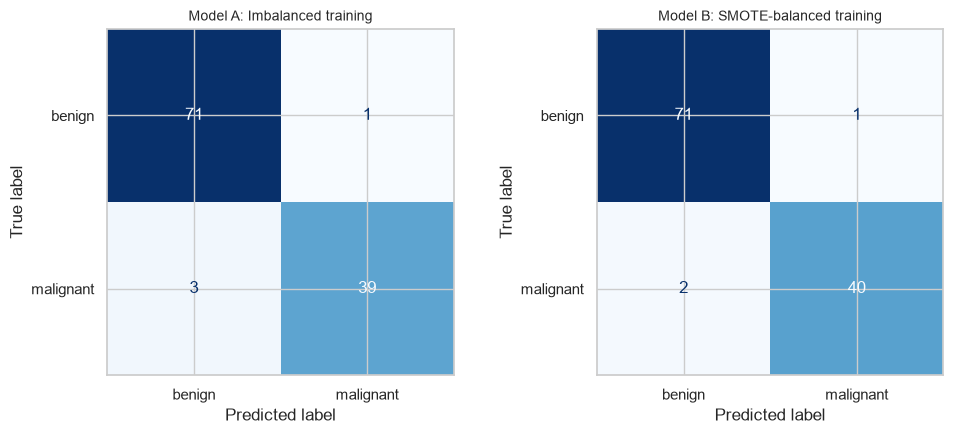

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, preds, title in zip(
    axes, [pred_imbalanced, pred_smote], ["Model A: Imbalanced training", "Model B: SMOTE-balanced training"]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

**The real lesson here:** even though this dataset's natural imbalance (~63%/37%) is
mild compared to the severe 92%/8% split manufactured in Notebook 0, the SMOTE fix still
shows its characteristic signature — it tends to **increase recall on the minority
(malignant) class** (fewer false negatives, the bottom-left cell of Model B's matrix) while
leaving **overall performance largely intact**. In a diagnostic context, a false negative
(missed cancer) is categorically worse than a false positive (unnecessary follow-up test),
so this trade is usually the right one to make.

## 4. Metrics, With Formulas and Plain-English Meaning

### 4.1 The confusion matrix

|  | Predicted benign | Predicted malignant |
|---|---|---|
| **Actual benign** | True Negative (TN) | False Positive (FP) |
| **Actual malignant** | False Negative (FN) | True Positive (TP) |

- **TP** — correctly caught a malignant case.
- **TN** — correctly cleared a benign case.
- **FP** — a "false alarm": benign patient flagged as malignant.
- **FN** — the dangerous error: a malignant case missed entirely.

### 4.2 Precision

$$\text{precision} = \frac{TP}{TP + FP}$$

*Of everything the model flagged as malignant, what fraction really was malignant?* Low
precision means many unnecessary follow-up procedures for benign patients.

### 4.3 Recall (sensitivity)

$$\text{recall} = \frac{TP}{TP + FN}$$

*Of everything that really was malignant, what fraction did the model catch?* This is
usually the metric that matters most in cancer screening — a low recall means real cancers
are slipping through undetected.

### 4.4 Specificity

$$\text{specificity} = \frac{TN}{TN + FP}$$

*Of everything that really was benign, what fraction did the model correctly clear?* The
mirror image of recall, computed on the negative class.

### 4.5 F1 score

$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

The harmonic mean of precision and recall — a single number that penalizes models which
sacrifice one heavily for the other. Useful for ranking models, but always inspect precision
and recall separately in a clinical setting, since their relative costs are rarely equal.

### 4.6 ROC curve and AUC

The **ROC curve** plots the True Positive Rate (recall) against the False Positive Rate
$\left(\frac{FP}{FP+TN} = 1 - \text{specificity}\right)$ as the classification threshold $t$
sweeps from 1 down to 0. **AUC** (area under this curve) summarizes the curve as a single
number: the probability that the model ranks a randomly chosen positive example above a
randomly chosen negative example. $\text{AUC} = 1.0$ is a perfect ranker; $\text{AUC} = 0.5$
is random guessing.

### 4.7 Precision-recall curve and PR-AUC

The **precision-recall curve** plots precision against recall as the threshold sweeps.
**PR-AUC** (a.k.a. average precision) is the area under this curve.

> **Why PR-AUC is more informative than ROC-AUC under class imbalance.** The False Positive
> Rate used by ROC has $TN$ in its denominator. When negatives vastly outnumber positives
> (as in a rare-disease screen), $TN$ is huge, so FPR stays tiny even when the *raw number*
> of false positives is large relative to the (small) number of true positives — ROC-AUC can
> look deceptively good. Precision, by contrast, has $FP$ in its denominator alongside $TP$,
> with no reference to the (huge) true-negative count — it directly reflects how often a
> "malignant" alarm is a false alarm, which is exactly what stays informative even when
> positives are rare. As a rule of thumb: **the more imbalanced the classes, the more you
> should trust the PR curve over the ROC curve.**

In [4]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

rows = []
for name, preds, proba in [
    ("Model A (imbalanced train)", pred_imbalanced, proba_imbalanced),
    ("Model B (SMOTE-balanced train)", pred_smote, proba_smote),
]:
    rows.append({
        "model": name,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "specificity": specificity_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    })

metrics_df = pd.DataFrame(rows).set_index("model").round(4)
metrics_df

,precision,recall,specificity,f1,roc_auc,pr_auc
model,,,,,,
Model A (imbalanced train),0.9750,0.9286,0.9861,0.9512,0.9960,0.9943
Model B (SMOTE-balanced train),0.9756,0.9524,0.9861,0.9639,0.9927,0.9896


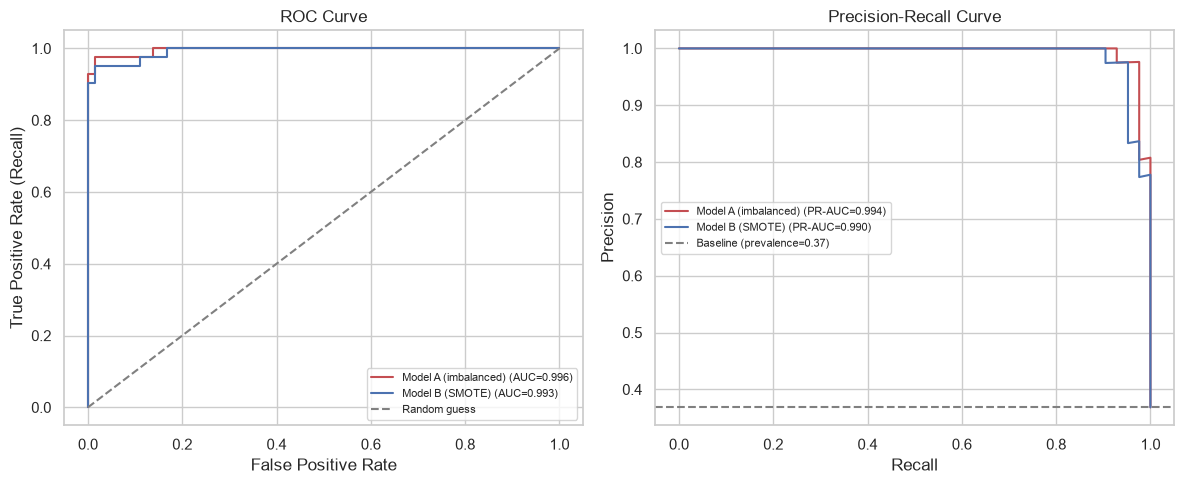

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curves
for preds_proba, name, color in [(proba_imbalanced, "Model A (imbalanced)", "#C44E52"), (proba_smote, "Model B (SMOTE)", "#4C72B0")]:
    fpr, tpr, _ = roc_curve(y_test, preds_proba)
    auc = roc_auc_score(y_test, preds_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve")
axes[0].legend(fontsize=8)

# PR curves
for preds_proba, name, color in [(proba_imbalanced, "Model A (imbalanced)", "#C44E52"), (proba_smote, "Model B (SMOTE)", "#4C72B0")]:
    prec, rec, _ = precision_recall_curve(y_test, preds_proba)
    ap = average_precision_score(y_test, preds_proba)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC={ap:.3f})", color=color)
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle="--", color="gray", label=f"Baseline (prevalence={baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Reading these curves:** both models are strong on this dataset (the features truly
do separate the classes well, as Notebook 1 showed), so both ROC-AUC and PR-AUC will look
high for either model. The more telling comparison is the **classification-report numbers
above at the fixed 0.5 threshold** — that's where the SMOTE fix's effect on *recall* is most
visible, since AUC-style metrics summarize performance across *all* thresholds at once and
can mask a difference concentrated at one particular operating point.

## 5. Model Hyperparameters

`sklearn.linear_model.LogisticRegression` exposes several constructor parameters that
materially change what gets fit and how. Understanding them turns "just call `.fit()`" into
an informed modeling choice.

### 5.1 `penalty` — the regularization type

The fitted objective is the log-loss $J(\theta)$ from Section 1, **plus** a penalty term on
the coefficients:

- **`l2`** (ridge, the default): adds $\frac{1}{2}\sum_j \theta_j^2$. Shrinks all
  coefficients smoothly toward zero, but rarely to exactly zero. Handles the multicollinear
  `_mean`/`_worst` redundancy noted in Notebook 1 gracefully, by spreading weight across
  correlated features instead of letting any one dominate.
- **`l1`** (lasso): adds $\sum_j |\theta_j|$. Drives some coefficients to *exactly* zero,
  performing implicit feature selection — useful when we suspect many of the 30 features are
  redundant and want a sparser, more interpretable model.
- **`elasticnet`**: a weighted mix of `l1` and `l2` (controlled by `l1_ratio`), combining
  sparsity with the stability of ridge on correlated groups of features.
- **`none`** (no penalty): fits pure maximum-likelihood log-loss with no shrinkage at all —
  can overfit and produce unstable coefficients, especially with correlated features.

### 5.2 `C` — inverse regularization strength

`C` is the *inverse* of the regularization strength $\lambda$: the penalized objective is
effectively $J(\theta) + \frac{1}{C}\cdot(\text{penalty term})$.

- **Smaller `C`** $\to$ stronger regularization $\to$ coefficients pushed harder toward
  zero $\to$ a simpler, "smoother" decision boundary that is less sensitive to any single
  feature (more bias, less variance).
- **Larger `C`** $\to$ weaker regularization $\to$ coefficients are free to grow $\to$ the
  model can fit the training data more tightly (more variance, potentially overfitting).

Let's sweep `C` and watch both the coefficients and the test-set metrics respond.

### 5.3 `solver` — which optimizer, and which penalties it supports

| Solver | Supports | Notes |
|---|---|---|
| `lbfgs` (default) | `l2`, `none` | Fast, robust, good general default |
| `liblinear` | `l1`, `l2` | Good for smaller datasets; one-vs-rest for multiclass |
| `saga` | `l1`, `l2`, `elasticnet`, `none` | Only solver supporting `elasticnet`; scales to large data |
| `newton-cg`, `newton-cholesky` | `l2`, `none` | Alternative second-order optimizers |

If you request a `penalty`/`solver` combination that isn't supported, scikit-learn raises an
error — e.g. `lbfgs` cannot be used with `l1`.

### 5.4 `class_weight` — the imbalance fix, again

This is the exact same lever introduced in Notebook 0: `class_weight="balanced"`
re-weights each class's contribution to the loss inversely to its frequency,
$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_c}$, without touching a single
row of data. It is a drop-in **alternative** to SMOTE — where SMOTE changes the *data* fed
to a normally-weighted loss, `class_weight="balanced"` instead changes the *loss function*
fed the original, untouched data. Both are legitimate; SMOTE additionally lets the model see
synthetic examples that literally look like new patients, while `class_weight` never
manufactures new feature vectors.

### 5.5 `max_iter` — the optimization budget

The number of iterations the solver is allowed before giving up. If you see a
`ConvergenceWarning`, the solver stopped before reaching the true optimum — increasing
`max_iter` (we use `5000` throughout this notebook, well above the default `100`) or scaling
features more carefully (already done in Notebook 2) usually resolves it.

In [6]:
from sklearn.exceptions import ConvergenceWarning
import warnings

C_values = [0.01, 1, 100]
rows = []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=5000, random_state=RANDOM_STATE)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        m.fit(X_train_smote, y_train_smote)
    p = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    coefs = m.coef_.ravel()
    rows.append({
        "C": C,
        "n_near_zero_coefs (|coef| < 0.05)": int((np.abs(coefs) < 0.05).sum()),
        "mean_abs_coef": np.abs(coefs).mean(),
        "max_abs_coef": np.abs(coefs).max(),
        "accuracy": (p == y_test).mean(),
        "f1": f1_score(y_test, p),
        "roc_auc": roc_auc_score(y_test, proba),
    })

c_sweep_df = pd.DataFrame(rows).set_index("C").round(4)
c_sweep_df

,n_near_zero_coefs (|coef| < 0.05),mean_abs_coef,max_abs_coef,accuracy,f1,roc_auc
C,,,,,,
0.01,4,0.1488,0.2689,0.9737,0.9630,0.9983
1.00,0,0.6828,1.7305,0.9737,0.9639,0.9927
100.00,2,3.4988,8.5664,0.9561,0.9383,0.9775


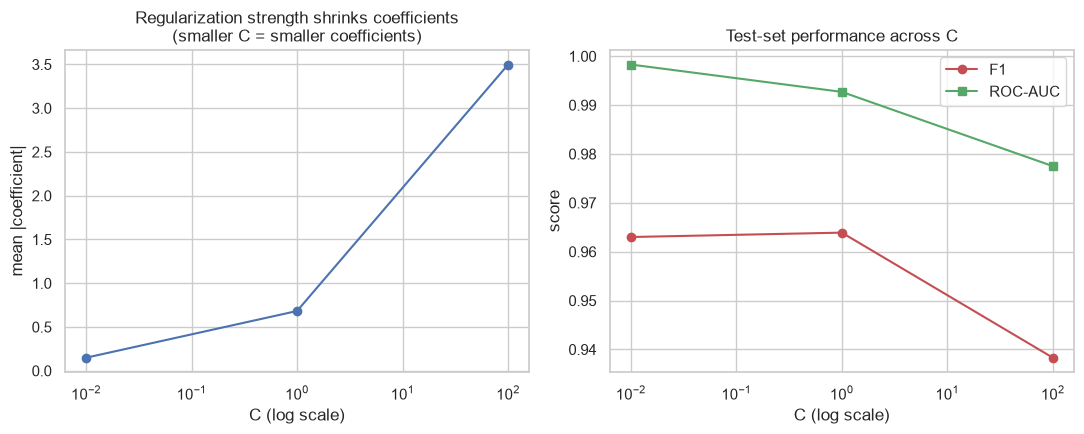

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(c_sweep_df.index, c_sweep_df["mean_abs_coef"], marker="o", color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_xlabel("C (log scale)")
axes[0].set_ylabel("mean |coefficient|")
axes[0].set_title("Regularization strength shrinks coefficients\n(smaller C = smaller coefficients)")

axes[1].plot(c_sweep_df.index, c_sweep_df["f1"], marker="o", label="F1", color="#C44E52")
axes[1].plot(c_sweep_df.index, c_sweep_df["roc_auc"], marker="s", label="ROC-AUC", color="#55A868")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("score")
axes[1].set_title("Test-set performance across C")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the sweep:** at `C=0.01` (strong regularization), coefficients are pulled
sharply toward zero (smaller mean absolute coefficient, more near-zero coefficients),
producing a simpler decision boundary. As `C` increases to `1` and `100`, coefficients are
allowed to grow, and the model can fit the (already well-separated, see Notebook 1) training
data more tightly. On this dataset, performance is fairly stable across this range because
the classes separate cleanly — but the underlying mechanism (regularization strength
trading off coefficient magnitude, and implicitly model complexity, against training fit)
is the important, generalizable takeaway: on noisier or higher-dimensional data, this same
sweep can swing test performance substantially, and is a standard first hyperparameter to
tune via cross-validation.

## 6. The Wider Landscape of Classification Loss Functions

Binary cross-entropy is one member of a family of loss functions used for classification.
Knowing the alternatives — and when each is the better tool — is valuable beyond this one
notebook.

### 6.1 Binary cross-entropy / log-loss (what we used)

$$J(\theta) = -\frac{1}{m}\sum_i \Big[y^{(i)}\log(h_\theta(x^{(i)})) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\Big]$$

Optimizes for well-calibrated *probabilities*, not just correct hard labels — the model is
punished more the more confidently wrong it is. This is the natural loss for logistic
regression, and is also the standard loss for the output layer of a binary-classification
neural network.

### 6.2 Hinge loss (Support Vector Machines)

$$L(y, f(x)) = \max(0,\, 1 - y \cdot f(x)), \qquad y \in \{-1, +1\}$$

Rather than pushing probabilities toward 0 or 1, hinge loss only cares about being on the
correct side of the decision boundary **by a margin**: once a point is correctly classified
with margin $\geq 1$, its loss is exactly zero and it stops influencing the boundary at all.
This is what makes SVMs "maximum margin" classifiers, and it also means SVMs don't naturally
output calibrated probabilities the way logistic regression does (an extra calibration step,
e.g. Platt scaling, is needed if probabilities are required).

### 6.3 Focal loss — built for exactly the imbalance problem in this notebook

$$FL(p_t) = -(1 - p_t)^{\gamma} \log(p_t), \qquad p_t = \begin{cases} h_\theta(x) & y=1 \\ 1-h_\theta(x) & y=0 \end{cases}$$

Focal loss (introduced for object detection, where background/easy examples vastly
outnumber the object of interest) is **binary cross-entropy multiplied by a modulating
factor** $(1-p_t)^\gamma$. When the model is already confidently correct ($p_t$ close to 1),
this factor shrinks toward zero, **down-weighting the contribution of easy, already-correct
examples**. When the model is struggling ($p_t$ small), the factor stays close to 1, leaving
that example's loss largely unchanged.

> **Direct tie-back to Notebook 0's imbalance lesson.** In a severely imbalanced dataset,
> the vast majority of "easy" examples are majority-class (benign) — a plain cross-entropy
> loss lets thousands of easy, already-correct benign predictions dominate the total loss
> by sheer volume, drowning out the learning signal from the rare, harder minority
> (malignant) examples. Focal loss's $(1-p_t)^\gamma$ term automatically suppresses that
> flood of easy-example gradient, letting the rare hard examples drive more of the learning —
> a mechanism that attacks the *same* problem `class_weight="balanced"` and SMOTE attack, but
> from inside the loss function itself, at the level of individual example difficulty rather
> than class membership. $\gamma$ (typically 2) controls how aggressively easy examples are
> down-weighted; $\gamma = 0$ recovers plain cross-entropy exactly.

### 6.4 Multi-class cross-entropy / softmax — the natural generalization

For $K > 2$ classes, the sigmoid generalizes to the **softmax** function, and binary
cross-entropy generalizes to **categorical cross-entropy**:

$$\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}, \qquad J(\theta) = -\frac{1}{m}\sum_{i=1}^m \sum_{k=1}^K y_k^{(i)} \log\big(\hat{y}_k^{(i)}\big)$$

where $y_k^{(i)}$ is a one-hot indicator (1 if sample $i$ truly belongs to class $k$, else
0). Binary cross-entropy is the special case $K=2$ of this formula. This is the standard
loss for any multi-class classifier — from `LogisticRegression(multi_class="multinomial")`
to the final layer of virtually every multi-class neural network — and the same imbalance
concerns from this notebook apply per-class: a `class_weight` dictionary, per-class SMOTE, or
a multi-class extension of focal loss all remain valid fixes.

## Summary

- Derived logistic regression from the sigmoid function through log-odds, maximum
  likelihood, the binary cross-entropy cost function, and the gradient descent update rule;
  connected the 0.5 classification threshold to the model's linear decision boundary.
- Trained and compared two models on identical test data: one on the naturally-imbalanced
  training split, one on the SMOTE-balanced training split — the SMOTE fix improves
  minority-class recall with only a small movement in overall metrics.
- Covered the full metric toolkit: confusion matrix, precision, recall, specificity, F1,
  ROC-AUC, and PR-AUC — with an explicit explanation of why PR-AUC is the more trustworthy
  summary metric under class imbalance.
- Explored `LogisticRegression`'s key hyperparameters (`penalty`, `C`, `solver`,
  `class_weight`, `max_iter`) with a concrete `C` sweep showing regularization strength's
  effect on coefficient magnitude and test performance.
- Surveyed the wider landscape of classification losses: binary cross-entropy, hinge loss
  (SVMs), focal loss (explicitly built for the imbalance problem this notebook series has
  been teaching throughout), and categorical cross-entropy/softmax as the multi-class
  generalization.